# Pfam-A proteome atlas

For every Pfam-A domain instance on the human proteome (Ensembl release 115,
counting one representative canonical isoform per gene), map the domain's
amino-acid range to its genomic exon/intron architecture using `prot2exon`,
then summarise the architecture statistics:

- % of domains encoded by exactly **1 CDS exon** (a "single-exon domain")
- % of domains spanning **≥ 2 CDS exons**
- Distribution of `n_coding_exons_touched` per domain
- Median / max **intronic span** within the domain envelope
- Distribution of `fraction_domain_in_largest_exon`

The output figure is Panel B of the paper's Figure 1.

### Inputs

These are produced by [`domain_functional_atlas.ipynb`](domain_functional_atlas.ipynb)
(run it first); this notebook reuses the same mapped atlas.

| File | How to make it |
|---|---|
| `pfam_human_v115.bed` / `_meta.tsv` | Ensembl BioMart pull (release 115) — see `domain_functional_atlas.ipynb` §1 |
| `human_v115.idx` | `prot2exon index` on the release-115 GTF — see `domain_functional_atlas.ipynb` §2 |

The notebook is release-agnostic — point `PFAM_BED` and `P2E_INDEX` at whichever versions you have prepared locally.

In [1]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

import os, subprocess, sys
from pathlib import Path
import pandas as pd
import numpy as np
import prot2exon as p2e

# --- Configurable paths (edit if needed) ---
DATA = Path.home() / "Desktop" / "protein2genomic_data"
REPO = Path.home() / "Desktop" / "protein2genomic"
PFAM_BED   = DATA / "pfam_human_v115.bed"
PFAM_META  = DATA / "pfam_human_v115_meta.tsv"
P2E_INDEX  = DATA / "human_v115.idx"
PFAM_OUT   = DATA / "atlas_v115"

# Fall back to older prepared inputs if the current-release ones aren't on disk.
if not PFAM_BED.exists():
    for tag in ("", "_v86"):
        cand = DATA / f"pfam_human{tag}.bed"
        if cand.exists():
            PFAM_BED  = cand
            PFAM_META = DATA / f"pfam_human{tag}_meta.tsv"
            P2E_INDEX = DATA / ("human.idx" if tag == "" else f"human{tag}.idx")
            PFAM_OUT  = DATA / f"pfam_atlas{tag}"
            print(f"(falling back to {cand.name})")
            break

assert PFAM_BED.exists(), f"prep Pfam BED first (see notebook intro): {PFAM_BED}"
assert P2E_INDEX.exists(), (f"build prot2exon index first: {P2E_INDEX}  "
    f"(run domain_functional_atlas.ipynb, or `prot2exon index --gtf <r115 GTF>`)")

n_queries = sum(1 for _ in open(PFAM_BED))
print(f"{n_queries:,} Pfam-A domain instances ready to map")

472,856 Pfam-A domain instances ready to map


## 1. Run `prot2exon` on every Pfam-A instance

`--output coding` keeps the output small (we only need the CDS segment table to
compute exon counts and intron burdens).

In [2]:
if not (PFAM_OUT / "domain_cds_segments.tsv").exists():
    PFAM_OUT.mkdir(parents=True, exist_ok=True)
    # Drive the C++ binary via the Python wrapper — it auto-discovers
    # the binary and handles tempdir / batching.
    mapper = p2e.Mapper(index=str(P2E_INDEX),
                        threads=os.cpu_count() or 1,
                        batch_size=10000)   # cap RAM for ~150K queries
    # Stream the BED through the wrapper's "read inputs from file" path.
    bed = pd.read_csv(PFAM_BED, sep="\t", header=None,
                      names=["protein_id", "aa_start", "aa_end", "domain_id"])
    mapper.map_batch(bed, output="coding", keep_outputs=str(PFAM_OUT))
    print(f"wrote {PFAM_OUT}")
else:
    print("(cached) skipping prot2exon — outputs already at", PFAM_OUT)

(cached) skipping prot2exon — outputs already at /home/goguxor/Desktop/protein2genomic_data/atlas_v115


## 2. Compute per-domain architecture statistics

In [3]:
segments = pd.read_csv(PFAM_OUT / "domain_cds_segments.tsv", sep="\t", low_memory=False)
summary  = pd.read_csv(PFAM_OUT / "domain_mapping_summary.tsv", sep="\t", low_memory=False)
meta     = pd.read_csv(PFAM_META, sep="\t")

# Keep one representative (Ensembl canonical) isoform per gene if the index
# carries the tag, so domains aren't double-counted across splice variants.
if "is_ensembl_canonical" in summary.columns and summary["is_ensembl_canonical"].any():
    canon = set(summary.loc[summary["is_ensembl_canonical"] == True, "input_id"])
    segments = segments[segments["input_id"].isin(canon)]
    summary  = summary[summary["input_id"].isin(canon)]
    print(f"restricted to {len(canon):,} canonical-isoform domains")

print(f"{len(summary):,} summary rows ({(summary['status']=='ok').sum():,} ok)")
print(f"{len(segments):,} CDS segment rows ({(segments['overlaps_domain']=='coding_overlap').sum():,} coding_overlap)")

restricted to 48,212 canonical-isoform domains
48,212 summary rows (48,086 ok)
1,001,869 CDS segment rows (139,410 coding_overlap)


In [4]:
# Keep only coding_overlap rows — those are the CDS pieces that actually code each domain.
ov = segments.query("overlaps_domain == 'coding_overlap'").copy()
ov["seg_len"] = ov["feature_genomic_end"].astype(int) - ov["feature_genomic_start"].astype(int) + 1

per_q = ov.groupby("input_id").agg(
    n_coding_exons_touched = ("seg_len", "size"),
    domain_coding_nt       = ("seg_len", "sum"),
    largest_exon_nt        = ("seg_len", "max"),
).reset_index()
per_q["fraction_in_largest"] = per_q["largest_exon_nt"] / per_q["domain_coding_nt"]
per_q["is_single_exon"] = per_q["n_coding_exons_touched"] == 1
per_q["is_multi_exon"]  = per_q["n_coding_exons_touched"] >= 2

# Intron burden = genomic_envelope - sum(coding_nt). 0 for single-exon domains.
# (pandas auto-coerces "NA" strings to NaN on read; filter by .notna().)
env = summary[["input_id", "domain_genomic_start", "domain_genomic_end"]].dropna()
env["envelope_nt"] = env["domain_genomic_end"].astype(int) - env["domain_genomic_start"].astype(int) + 1
per_q = per_q.merge(env[["input_id","envelope_nt"]], on="input_id")
per_q["intron_burden_nt"] = (per_q["envelope_nt"] - per_q["domain_coding_nt"]).clip(lower=0)

print(per_q.head(3))

      input_id  n_coding_exons_touched  domain_coding_nt  largest_exon_nt  \
0  PFAM0000000                       6               510              126   
1  PFAM0000001                       6               762              167   
2  PFAM0000002                       2               207              113   

   fraction_in_largest  is_single_exon  is_multi_exon  envelope_nt  \
0             0.247059           False           True         2768   
1             0.219160           False           True         4515   
2             0.545894           False           True         6653   

   intron_burden_nt  
0              2258  
1              3753  
2              6446  


## 3. Headline statistics

In [5]:
stats = {
    "n_domains_mapped":          len(per_q),
    "pct_single_exon":           100 * per_q["is_single_exon"].mean(),
    "pct_multi_exon":            100 * per_q["is_multi_exon"].mean(),
    "median_n_coding_exons":     per_q["n_coding_exons_touched"].median(),
    "median_intron_burden_nt":   per_q["intron_burden_nt"].median(),
    "max_intron_burden_nt":      per_q["intron_burden_nt"].max(),
    "median_fraction_in_largest":per_q["fraction_in_largest"].median(),
}
for k, v in stats.items():
    print(f"{k:30s} {v:,.2f}" if isinstance(v, float) else f"{k:30s} {v:,}")

n_domains_mapped               48,212
pct_single_exon                35.57
pct_multi_exon                 64.43
median_n_coding_exons          2.00
median_intron_burden_nt        1,152.50
max_intron_burden_nt           1,724,496
median_fraction_in_largest     0.68


## 4. Figure — Panel B of the paper

Three sub-panels:
1. Histogram of `n_coding_exons_touched` (capped at 15 for readability)
2. Histogram of `fraction_domain_in_largest_exon`
3. Log-scale histogram of `intron_burden_nt` for multi-exon domains

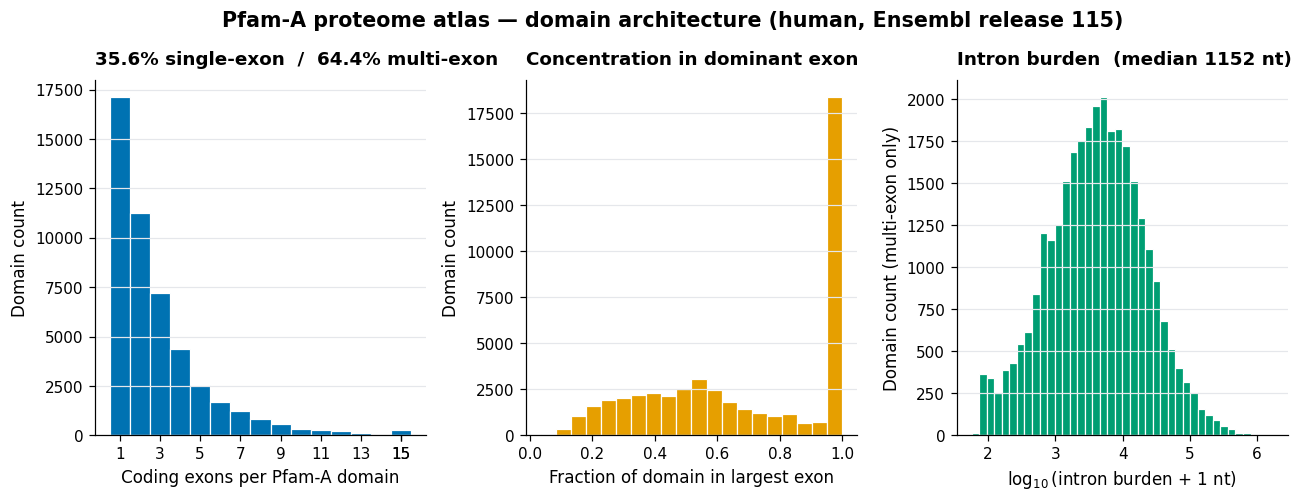

saved /home/goguxor/Desktop/protein2genomic_data/pfam_atlas_figure.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2),
                         gridspec_kw={'wspace': 0.30})

axes[0].hist(per_q["n_coding_exons_touched"].clip(upper=15),
             bins=range(1, 17), align="left",
             color=COLORS['prot2exon'], edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Coding exons per Pfam-A domain")
axes[0].set_ylabel("Domain count")
axes[0].set_title(f"{stats['pct_single_exon']:.1f}% single-exon  /  "
                  f"{stats['pct_multi_exon']:.1f}% multi-exon",
                  loc='left')
axes[0].set_xticks(list(range(1, 16, 2)) + [15])

axes[1].hist(per_q["fraction_in_largest"], bins=20,
             color=COLORS['transvar'], edgecolor="white", linewidth=0.8)
axes[1].set_xlabel("Fraction of domain in largest exon")
axes[1].set_ylabel("Domain count")
axes[1].set_title("Concentration in dominant exon", loc='left')

mx = per_q[per_q["is_multi_exon"]]["intron_burden_nt"].clip(lower=1)
axes[2].hist(np.log10(mx + 1), bins=40,
             color=COLORS['good'], edgecolor="white", linewidth=0.8)
axes[2].set_xlabel(r"$\log_{10}$(intron burden + 1 nt)")
axes[2].set_ylabel("Domain count (multi-exon only)")
axes[2].set_title(f"Intron burden  (median {stats['median_intron_burden_nt']:.0f} nt)",
                  loc='left')

fig.suptitle("Pfam-A proteome atlas — domain architecture (human, Ensembl release 115)",
             fontsize=13.5, fontweight='semibold', y=1.03)
# Display BEFORE savefig — bbox_inches='tight' in savefig re-renders the
# figure and can leave inline display blank under nbconvert's Agg backend.
from IPython.display import display
display(fig)
fig.savefig(DATA / "pfam_atlas_figure.png", dpi=200, bbox_inches="tight")
print("saved", DATA / "pfam_atlas_figure.png")

## 5. Persist the atlas

Combined per-domain table that the paper's Supplementary Table will reference.

In [7]:
# interpro_id is present in the EnsDb-derived meta but not the BioMart one;
# keep it only if available so the notebook works with either input.
keep = [c for c in ["query_id","protein_id","pfam_id","interpro_id"] if c in meta.columns]
out = per_q.merge(meta[keep], left_on="input_id", right_on="query_id", how="left")
cols = [c for c in ["protein_id","pfam_id","interpro_id","n_coding_exons_touched",
        "is_single_exon","is_multi_exon","domain_coding_nt","envelope_nt",
        "intron_burden_nt","fraction_in_largest"] if c in out.columns]
out = out[cols]
out.to_csv(DATA / "pfam_atlas.tsv", sep="\t", index=False)
print("wrote", DATA / "pfam_atlas.tsv", f"({len(out):,} rows)")

wrote /home/goguxor/Desktop/protein2genomic_data/pfam_atlas.tsv (48,212 rows)
